In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
# matplotlib.use('TkAgg')  # or 'QtAgg', etc.

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])

# Increase fonts globally (adjust sizes as needed)
# DEFAULT IS 12
plt.rcParams.update({
    'font.size': 15,            # default text size
    'axes.titlesize': 15,      # axes title
    'axes.labelsize': 15,      # x/y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend text
    'figure.titlesize': 15
})

In [2]:
# Import data
df_vo = pd.read_csv('data/log_21_2025-10-21-21-25-48_vehicle_odometry_0.csv')
df_vvo = pd.read_csv('data/log_21_2025-10-21-21-25-48_vehicle_visual_odometry_0.csv')

In [3]:
t_vvo = (df_vvo['timestamp'].to_numpy() - df_vvo['timestamp'].to_numpy()[0]) / 1e6
t_vo = (df_vo['timestamp'].to_numpy() - df_vo['timestamp'].to_numpy()[0]) / 1e6
pos1_vvo = df_vvo['position[0]'].to_numpy()
pos1_vo = df_vo['position[0]'].to_numpy()
pos3_vvo = -df_vvo['position[1]'].to_numpy()
pos3_vo = -df_vo['position[1]'].to_numpy()
pos2_vvo = df_vvo['position[2]'].to_numpy()
pos2_vo = df_vo['position[2]'].to_numpy()

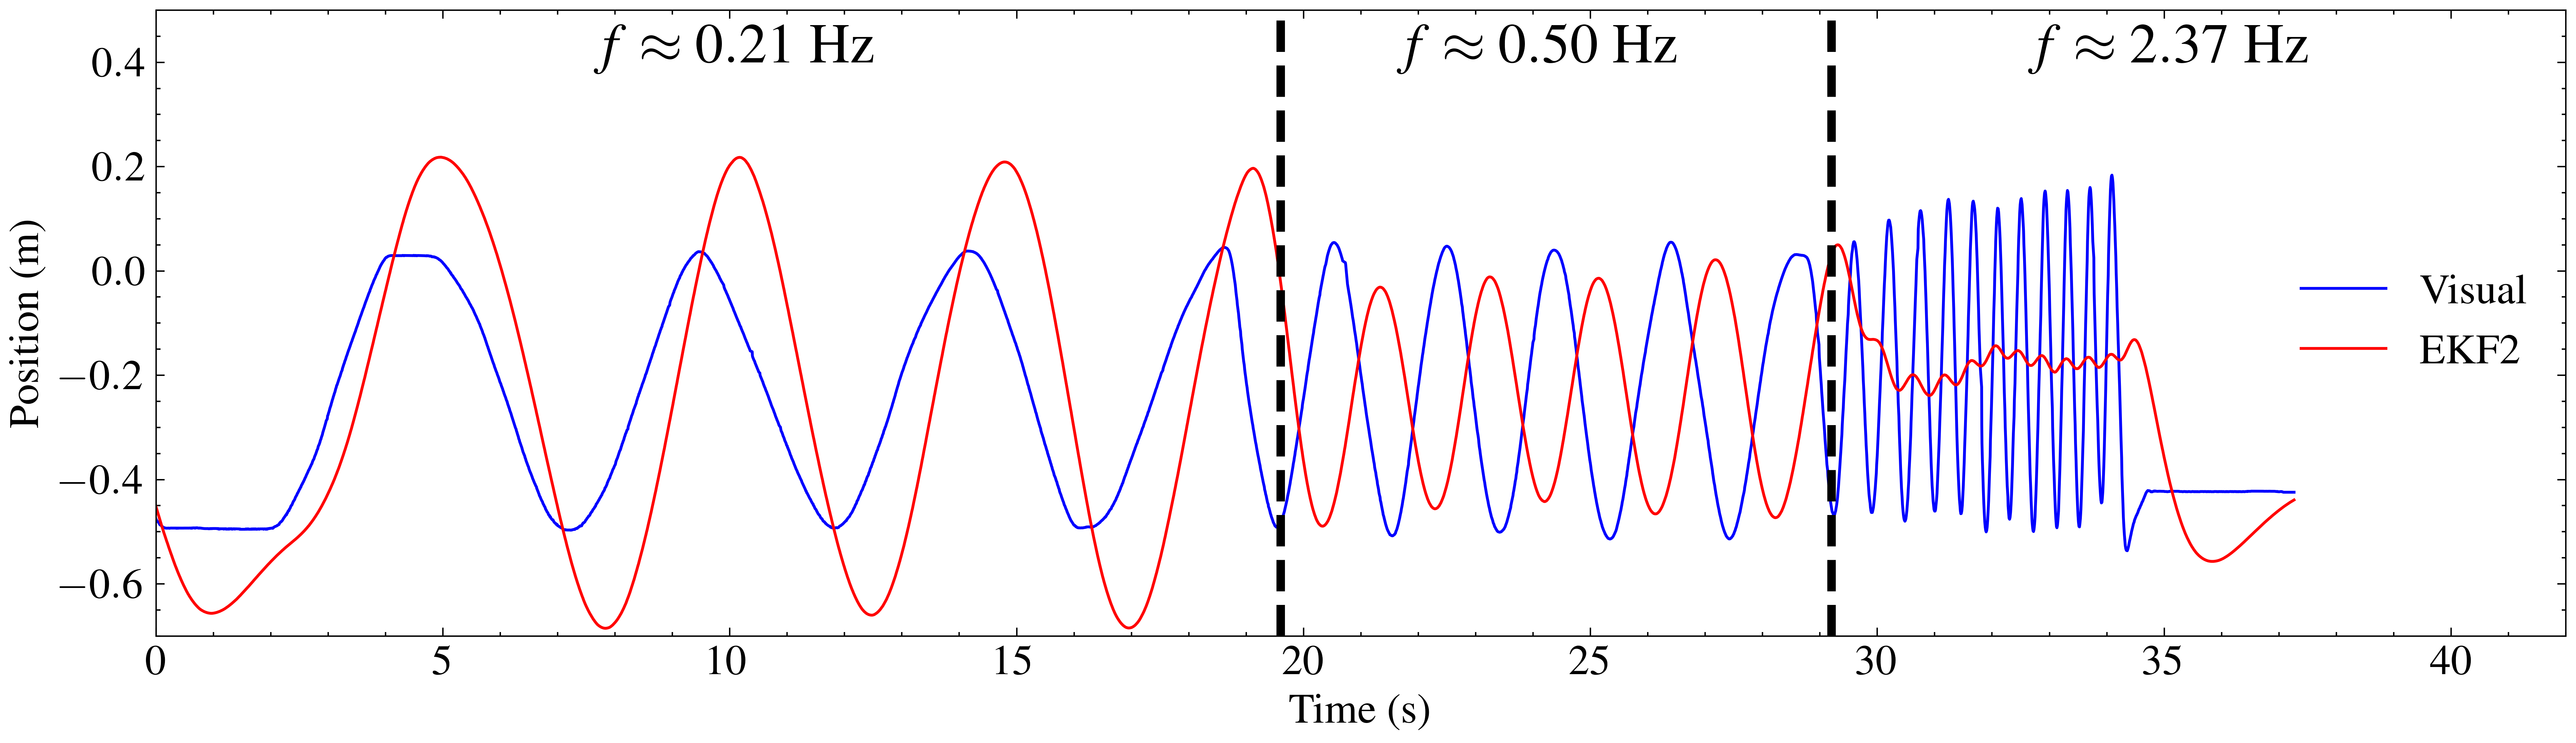

In [5]:
plt.figure(figsize=(13, 4))
plt.plot(t_vvo, pos2_vvo, '-', color='C02', label='Visual')
plt.plot(t_vo, pos2_vo, '-', color='C01', label='EKF2')
plt.axvline(x=19.6, color='k', linestyle='--', linewidth=3)
plt.axvline(x=29.2, color='k', linestyle='--', linewidth=3)
ax = plt.gca()
ax.text(10, 0.4, r"$f \approx 0.21$ Hz", fontsize=20, color='k', ha='center')
ax.text(24, 0.4, r"$f \approx 0.50$ Hz", fontsize=20, color='k', ha='center')
ax.text(35, 0.4, r"$f \approx 2.37$ Hz", fontsize=20, color='k', ha='center')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.xlim(0,42)
plt.ylim(-0.7, 0.5)
plt.legend(loc='right')
plt.savefig("oscillations_1.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [6]:
# ...existing code...
from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d
import numpy as np

def estimate_freq_region(t, x, tmin=None, tmax=None, resample_fs=None):
    mask = np.ones_like(t, dtype=bool)
    if tmin is not None: mask &= (t >= tmin)
    if tmax is not None: mask &= (t <= tmax)
    tseg = t[mask]
    xseg = x[mask]
    if len(tseg) < 4:
        return {'n_samples': len(tseg)}
    # check sampling regularity
    dt = np.diff(tseg)
    median_dt = np.median(dt)
    if resample_fs is None:
        resample_fs = 1.0/median_dt
    if np.max(np.abs(dt - median_dt)) > 0.02*median_dt:  # >2% nonuniform
        t_uniform = np.arange(tseg[0], tseg[-1], 1.0/resample_fs)
        interp = interp1d(tseg, xseg, kind='linear', fill_value='extrapolate')
        x_uniform = interp(t_uniform)
    else:
        t_uniform = tseg
        x_uniform = xseg
        resample_fs = 1.0/median_dt
    # detrend
    x_d = x_uniform - np.mean(x_uniform)
    # peak-based period
    peaks, _ = find_peaks(x_d, prominence=np.std(x_d)*0.3)
    if len(peaks) > 1:
        periods = np.diff(t_uniform[peaks])
        freq_peak = 1.0 / np.median(periods)
    else:
        freq_peak = np.nan
    # FFT / dominant freq
    n = len(x_d)
    yf = np.fft.rfft(x_d * np.hanning(n))
    xf = np.fft.rfftfreq(n, 1.0/resample_fs)
    pos = xf > 0
    if np.any(pos):
        freq_fft = xf[pos][np.argmax(np.abs(yf[pos]))]
    else:
        freq_fft = np.nan
    # Welch PSD
    nperseg = min(256, n)
    f_w, Pxx = welch(x_d, fs=resample_fs, nperseg=nperseg)
    f_w_pos = f_w > 0
    if np.any(f_w_pos):
        freq_welch = f_w[f_w_pos][np.argmax(Pxx[f_w_pos])]
    else:
        freq_welch = np.nan
    return {
        'n_samples': len(tseg),
        'resample_fs': resample_fs,
        'freq_peak': freq_peak,
        'freq_fft': freq_fft,
        'freq_welch': freq_welch,
        'n_peaks': len(peaks)
    }

regions = [('A', None, 19.6), ('B', 19.6, 29.2), ('C', 29.2, None)]
for name, a, b in regions:
    out = estimate_freq_region(t_vvo, pos3_vvo, tmin=a, tmax=b)
    print(f"Region {name}: samples={out.get('n_samples')}, peaks={out.get('n_peaks')}, "
          f"peak_freq={out.get('freq_peak'):.3f}, fft_freq={out.get('freq_fft'):.3f}, "
          f"welch_freq={out.get('freq_welch'):.3f}")
# ...existing code...

Region A: samples=2339, peaks=264, peak_freq=20.074, fft_freq=0.204, welch_freq=0.470
Region B: samples=1143, peaks=118, peak_freq=20.085, fft_freq=0.417, welch_freq=0.471
Region C: samples=967, peaks=23, peak_freq=4.597, fft_freq=5.088, welch_freq=5.135
